# Customer Support Quality Analysis


## Objective

Analyze customer support ticket performance by:

- Loading and cleaning the data
- Removing duplicate records
- Merging ticket and team datasets
- Creating SLA breach indicators
- Analyzing department and team performance
- Visualizing monthly resolution trends
- Exporting cleaned data and summaries

## Load Liabraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Step 1: Load Dataset

Load both raw CSV files into pandas DataFrames.

In [6]:
tickets = pd.read_csv(r'C:\Users\DEVANSHI\Desktop\Data_Analysis_Mock2\Data\tickets.csv')
teams = pd.read_csv(r'C:\Users\DEVANSHI\Desktop\Data_Analysis_Mock2\Data\teams.csv')

print("Tickets Shape:", tickets.shape)
print("Teams Shape:", teams.shape)

tickets.head()

Tickets Shape: (13, 6)
Teams Shape: (4, 3)


,ticket_id,month,team_id,channel,resolution_hours,satisfaction
0,1,Jan,T1,Email,12,4
1,2,Jan,T2,Chat,28,3
2,3,Jan,T3,Phone,36,2
3,4,Jan,T4,Email,20,4
4,5,Feb,T1,Chat,8,5


## Step 2: Data Cleaning

The tickets dataset contains one intentional duplicate row.

Remove the duplicate and verify row counts.

In [7]:
print("Rows Before Cleaning:", len(tickets))

tickets = tickets.drop_duplicates()

print("Rows After Cleaning:", len(tickets))

Rows Before Cleaning: 13
Rows After Cleaning: 12


## Step 3: Merge Datasets

Merge the tickets table with the teams lookup table using `team_id`.

In [8]:
df = pd.merge(
    tickets,
    teams,
    on='team_id',
    how='left'
)

df.head()

,ticket_id,month,team_id,channel,resolution_hours,satisfaction,team,department
0,1,Jan,T1,Email,12,4,AccountCare,Service
1,2,Jan,T2,Chat,28,3,BillingHelp,Service
2,3,Jan,T3,Phone,36,2,AppSupport,Technical
3,4,Jan,T4,Email,20,4,DeviceHelp,Technical
4,5,Feb,T1,Chat,8,5,AccountCare,Service


## Step 4: Data Validation

Validate:

- 12 rows remain after cleaning
- No unmatched team IDs exist

In [9]:
assert len(df) == 12

assert df['department'].isna().sum() == 0

print("Validation Passed")
print("Rows:", len(df))
print("Unmatched Keys:", df['department'].isna().sum())

Validation Passed
Rows: 12
Unmatched Keys: 0


## Step 5: Create SLA Breach Flag

Business Rule:

- breach_flag = 1 when resolution_hours > 24
- breach_flag = 0 otherwise

In [10]:
df['breach_flag'] = (
    df['resolution_hours'] > 24
).astype(int)

df.head()

,ticket_id,month,team_id,channel,resolution_hours,satisfaction,team,department,breach_flag
0,1,Jan,T1,Email,12,4,AccountCare,Service,0
1,2,Jan,T2,Chat,28,3,BillingHelp,Service,1
2,3,Jan,T3,Phone,36,2,AppSupport,Technical,1
3,4,Jan,T4,Email,20,4,DeviceHelp,Technical,0
4,5,Feb,T1,Chat,8,5,AccountCare,Service,0


## Step 6: Department Analysis

Calculate:

- Total Tickets
- Breached Tickets
- SLA Breach Rate (%)

In [11]:
dept_summary = df.groupby('department').agg(
    total_tickets=('ticket_id','count'),
    breached_tickets=('breach_flag','sum')
)

dept_summary['sla_breach_rate'] = (
    dept_summary['breached_tickets']
    / dept_summary['total_tickets']
    * 100
).round(2)

dept_summary

,total_tickets,breached_tickets,sla_breach_rate
department,,,
Service,6,2,33.33
Technical,6,3,50.00


## Step 7: Team-Level Analysis

Identify the team with the highest SLA breach rate.

In [12]:
team_summary = df.groupby('team').agg(
    total_tickets=('ticket_id','count'),
    breached_tickets=('breach_flag','sum')
)

team_summary['breach_rate'] = (
    team_summary['breached_tickets']
    / team_summary['total_tickets']
    * 100
).round(2)

team_summary.sort_values(
    by='breach_rate',
    ascending=False
)

,total_tickets,breached_tickets,breach_rate
team,,,
AppSupport,3,2,66.67
BillingHelp,3,2,66.67
DeviceHelp,3,1,33.33
AccountCare,3,0,0.00


## Step 8: Highest Breach Team

Display the team with the highest SLA breach rate.

In [13]:
highest = team_summary.sort_values(
    by='breach_rate',
    ascending=False
).head(1)

highest

,total_tickets,breached_tickets,breach_rate
team,,,
AppSupport,3,2,66.67


## Step 9: Monthly Resolution Performance

Compute monthly average resolution time.

In [14]:
month_order = ['Jan','Feb','Mar']

monthly_avg = (
    df.groupby('month')['resolution_hours']
    .mean()
    .reindex(month_order)
)

monthly_avg

month
Jan    24.0
Feb    24.0
Mar    23.5
Name: resolution_hours, dtype: float64

## Step 10: Visualization

Create a chart showing average resolution hours by month.

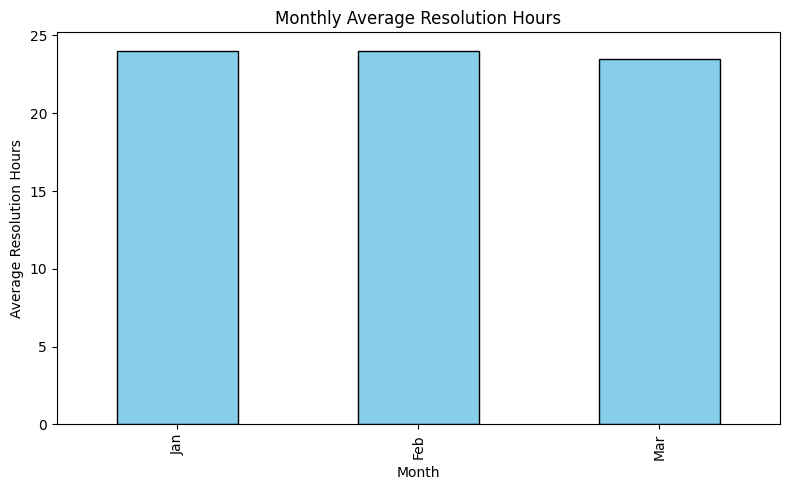

In [16]:
plt.figure(figsize=(8,5))

monthly_avg.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title('Monthly Average Resolution Hours')
plt.xlabel('Month')
plt.ylabel('Average Resolution Hours')

plt.tight_layout()

plt.savefig('C:\\Users\\DEVANSHI\\Desktop\\Data_Analysis_Mock2\\Outputs\\python_chart.png')

plt.show()

## Step 11: Export Results

Export:

1. Clean merged data
2. Department summary
3. Chart image

In [20]:
df.to_csv(
    'C:\\Users\\DEVANSHI\\Desktop\\Data_Analysis_Mock2\\Outputs\\clean_data.csv',
    index=False
)

dept_summary.to_csv(
    'C:\\Users\\DEVANSHI\\Desktop\\Data_Analysis_Mock2\\Outputs\\python_summary.csv'
)

print("clean_data.csv exported")
print("python_summary.csv exported")
print("python_chart.png saved")

clean_data.csv exported
python_summary.csv exported
python_chart.png saved


# Conclusion

## Key Findings

### Department Performance

| Department | Tickets | Breaches | Breach Rate |
|------------|----------|----------|-------------|
| Service | 6 | 2 | 33.33% |
| Technical | 6 | 3 | 50.00% |

### Highest Risk Team

- Team: AppSupport
- Breached Tickets: 2
- Total Tickets: 3
- Breach Rate: 66.67%

### Recommendation

The Technical department should be prioritized for SLA improvement initiatives because it has a higher breach rate than the Service department.